# 2.0-feature-engineering

## Imports

In [1]:
import pandas as pd
import pingouin as pg
import matplotlib.pyplot as plt
import statsmodels.api as sm
from itertools import pairwise
from recruit_restaurant_visitor_forecasting.config.config import (
    AIR_AREA_COL,
    AIR_GENRE_COL,
    AIR_RESTAURANT_ID_COL,
    CALENDAR_DATE_COL,
    HPG_RESTAURANT_ID_COL,
    LATITUDE_COL,
    LONGITUDE_COL,
    VISIT_DATE_COL,
    VISITORS_COL,
    INTERIM_DATA_DIR,
    PROCESSED_DATA_DIR,
    RAW_DATA_DIR,
    RANDOM_SEED,
    PROJ_ROOT,
    HOLIDAY_COL,
)
from recruit_restaurant_visitor_forecasting.config.features import (
    CITY_COL,
    DAY_OF_WEEK_COL,
    DAYS_OF_WEEK,
    OPEN_DATE_COL,
    RESERVE_AIR_COL,
    RESERVE_AIR_NBR_COL,
    RESERVE_HPG_COL,
    RESERVE_HPG_NBR_COL,
    TOTAL_RES_COL,
    TOTAL_RES_NBR_COL,
    VISITORS_NBR_COL,
    VISITORS_DOW,
    VISITORS_DOW_NBRS,
    RES_VISITORS_DIFF_COL,
    RES_VISITORS_DIFF_NBR_COL,
    GENRE_TE,
    AREA_TE,
    MEAN_PREF,
    MAX_PREF,
    MEDIAN_PREF,
    OPEN_USUALLY_COL,
    MIN_PREF,
    STD_PREF,
    RES_IMPOSSIBILITY_COL,
    AGG_WINDOWS,
    OPENED_RECENTLY_FLG,
    DAYS_FROM_HOL_COL,
    GOLDEN_WEEK_FLG,
    DOW_WINDOW,
    CLOSED_FLG
)
from recruit_restaurant_visitor_forecasting.config.preprocessing import (
    VARIANCE_FS_THRESHOLD, TARGET_CORR_THRESHOLD
)
from recruit_restaurant_visitor_forecasting.dataset import (
    prepare_datetime_columns, standardize_date
)
from recruit_restaurant_visitor_forecasting.features import (
    add_basic_stats,
    add_golden_week_flg,
    add_dow_cum_agg,
    add_holiday_columns,
    add_lags,
    add_last_month_visitors,
    add_nbrs_reserves,
    add_neighbors_stats,
    add_opened_recently_flg,
    add_reserves_difference,
    add_sum_of_reserves,
    add_time_based_target_encoding,
    add_total_nbr_reservations,
    add_total_reservations,
    drop_first_month,
    add_open_usually_col,
    add_reservation_impossibility,
    select_by_vif,
    get_features_by_variance_threshold,
    get_features_by_target_corr,
    add_open_usually_discr,
    add_open_usually_col_rolling,
    add_open_usually_discr_rolling,
    add_dow_rol_agg,
    add_closed_flg
)
from recruit_restaurant_visitor_forecasting.config.feature_names import agg_window_col, agg_exp_col
from recruit_restaurant_visitor_forecasting.plots import plot_corr_matrix, plot_pairs_rel
from recruit_restaurant_visitor_forecasting.utils import (
    get_pairs_by_corr, get_visitors_by_zero_res, get_non_outliers_mask
)
from recruit_restaurant_visitor_forecasting.eda import show_open_usually_stats

2026-04-24 20:42:33.771 | INFO     | recruit_restaurant_visitor_forecasting.config.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
air_visit_df = pd.read_csv(INTERIM_DATA_DIR / 'air_visit.csv')
air_reserve_df = pd.read_csv(INTERIM_DATA_DIR / 'air_reserve.csv')
hpg_reserve_df = pd.read_csv(INTERIM_DATA_DIR / 'hpg_reserve.csv', dtype={AIR_RESTAURANT_ID_COL: str})
future_df = pd.read_csv(INTERIM_DATA_DIR / 'sample_submission.csv')
air_store_df = pd.read_csv(INTERIM_DATA_DIR / 'air_store_info.csv')
hpg_store_df = pd.read_csv(INTERIM_DATA_DIR / 'hpg_store_info.csv')
date_info_df = pd.read_csv(RAW_DATA_DIR / 'date_info.csv')
store_rel_df = pd.read_csv(RAW_DATA_DIR / 'store_id_relation.csv')

In [3]:
prepare_datetime_columns(air_reserve_df)
prepare_datetime_columns(hpg_reserve_df)

standardize_date(date_info_df, CALENDAR_DATE_COL)
standardize_date(air_visit_df, VISIT_DATE_COL)
standardize_date(future_df, VISIT_DATE_COL)

## Features

### Air & hpg stores

In [4]:
air_store_df = air_store_df.drop([AIR_AREA_COL, LATITUDE_COL, LONGITUDE_COL], axis=1)

### Reserve dataframes

For further work, it is necessary to know the total number of reservations in the restaurant per day.

In [5]:
air_res_sum = add_sum_of_reserves(air_reserve_df, RESERVE_AIR_COL)
air_res_sum = air_res_sum.merge(
    air_store_df[[AIR_RESTAURANT_ID_COL, CITY_COL]],
    on=AIR_RESTAURANT_ID_COL
)
air_res_sum = add_nbrs_reserves(air_res_sum, RESERVE_AIR_COL, CITY_COL, RESERVE_AIR_NBR_COL)
air_res_sum.head()

,air_store_id,visit_date,air_reserves,city,air_reserves_nbrs
0,air_00a91d42b08b08d9,2016-10-31,2,Tōkyō-to,7.829268
1,air_00a91d42b08b08d9,2016-12-05,9,Tōkyō-to,9.754717
2,air_00a91d42b08b08d9,2016-12-14,18,Tōkyō-to,13.726027
3,air_00a91d42b08b08d9,2016-12-17,2,Tōkyō-to,20.884211
4,air_00a91d42b08b08d9,2016-12-20,4,Tōkyō-to,14.944444


In [6]:
air_res_sum[RESERVE_AIR_NBR_COL].isna().sum()

np.int64(0)

However, air_reserve dataframe still has a large number of gaps.

In [7]:
hpg_res_sum = add_sum_of_reserves(hpg_reserve_df, RESERVE_HPG_COL, HPG_RESTAURANT_ID_COL)
hpg_res_sum = hpg_res_sum.merge(
    hpg_store_df[[HPG_RESTAURANT_ID_COL, CITY_COL]],
    on=HPG_RESTAURANT_ID_COL
)
hpg_res_sum = add_nbrs_reserves(hpg_res_sum, RESERVE_HPG_COL, CITY_COL, RESERVE_HPG_NBR_COL)
hpg_res_sum.head()

,hpg_store_id,visit_date,hpg_reserves,city,hpg_reserves_nbrs
0,hpg_001ce40a1f873e4f,2016-01-13,4,Ōsaka-fu,5.573913
1,hpg_001ce40a1f873e4f,2016-01-27,7,Ōsaka-fu,6.202614
2,hpg_001ce40a1f873e4f,2016-02-13,2,Ōsaka-fu,6.532915
3,hpg_001ce40a1f873e4f,2016-02-27,8,Ōsaka-fu,7.452012
4,hpg_001ce40a1f873e4f,2016-03-16,2,Ōsaka-fu,7.291892


In [8]:
hpg_res_sum[RESERVE_HPG_NBR_COL].isna().sum()

np.int64(0)

In [9]:
hpg_res_sum_mapped = hpg_res_sum.merge(
    store_rel_df,
    on=HPG_RESTAURANT_ID_COL
)

### Date info

It is necessary to add a feature for the distance to the nearest holiday.

In [10]:
date_info_df = add_holiday_columns(date_info_df, CALENDAR_DATE_COL)

It is also necessary to designate Golden Week, since not all days of this week are holidays.

In [11]:
date_info_df = add_golden_week_flg(date_info_df, [2016, 2017], CALENDAR_DATE_COL)

Later we will need to match the weekday of a selected date with the restaurant’s open/closed flag for that weekday, so it makes sense to rename the days.

In [12]:
FULL_WEEKDAYS = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
mapping = dict(zip(FULL_WEEKDAYS, DAYS_OF_WEEK))
date_info_df[DAY_OF_WEEK_COL] = date_info_df[DAY_OF_WEEK_COL].replace(mapping)

### Air visit

#### Start dates

We can consider the restaurant's opening date. Since simply counting the number of days since opening may not be sufficient due to the increase in days over time, it's best to flag the restaurant's opening as occurring within the last six months. A **potential issue**: some restaurants either planned to open earlier than their minimum opening date but didn't, or didn't report visitors for earlier dates. This is indicated by the fact that air_reserve dataframe has reservations for earlier dates.

In [13]:
air_open_dates = (
    air_visit_df.groupby(AIR_RESTAURANT_ID_COL)[VISIT_DATE_COL]
    .min()
    .rename(OPEN_DATE_COL)
)

In [14]:
air_visit_df = add_opened_recently_flg(
    air_visit_df, air_open_dates, VISIT_DATE_COL, AIR_RESTAURANT_ID_COL
)
future_df = add_opened_recently_flg(
    future_df, air_open_dates, VISIT_DATE_COL, AIR_RESTAURANT_ID_COL
)

In [15]:
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1


In [16]:
future_df.head()

,id,visitors,air_store_id,visit_date,open_date,opened_recently
0,air_00a91d42b08b08d9_2017-04-23,0,air_00a91d42b08b08d9,2017-04-23,2016-07-01,0
1,air_00a91d42b08b08d9_2017-04-24,0,air_00a91d42b08b08d9,2017-04-24,2016-07-01,0
2,air_00a91d42b08b08d9_2017-04-25,0,air_00a91d42b08b08d9,2017-04-25,2016-07-01,0
3,air_00a91d42b08b08d9_2017-04-26,0,air_00a91d42b08b08d9,2017-04-26,2016-07-01,0
4,air_00a91d42b08b08d9_2017-04-27,0,air_00a91d42b08b08d9,2017-04-27,2016-07-01,0


#### Open dates

In [17]:
air_visit_df = air_visit_df.merge(
    date_info_df,
    left_on=VISIT_DATE_COL,
    right_on=CALENDAR_DATE_COL
).merge(
    air_store_df,
    on=AIR_RESTAURANT_ID_COL
).drop(CALENDAR_DATE_COL, axis=1)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,city
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,Tōkyō-to
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,Tōkyō-to
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,Tōkyō-to
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,Tōkyō-to
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,Tōkyō-to


In [18]:
air_visit_df = add_open_usually_col(air_visit_df)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,city,open_usually
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,Tōkyō-to,0.794747
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,Tōkyō-to,0.729329
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,Tōkyō-to,0.003934
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,Tōkyō-to,0.625874
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,Tōkyō-to,0.811994


Open_usually feature contains the probability that a restaurant will be open on a given day. It depends on the holiday feature, the percentage of non-zeros on holidays, and on individual days of the week.

In [19]:
# TODO: add open_usually feature to the future_df
future_df = future_df.merge(
    date_info_df,
    left_on=VISIT_DATE_COL,
    right_on=CALENDAR_DATE_COL
).merge(
    air_store_df,
    on=AIR_RESTAURANT_ID_COL
).drop(CALENDAR_DATE_COL, axis=1)
# future_df = add_open_usually(future_df)
# future_df.head()

#### Mean visitors by air city.

It is necessary to make smoothed target encoding, while the average value will be used for new areas. In this case, it is worth considering only days when the number of visitors is not zero, so that only open restaurants are taken into account.

In [20]:
air_visit_df, future_df = add_time_based_target_encoding(
    air_visit_df,
    future_df,
    CITY_COL,
    VISITORS_COL,
    AREA_TE
)

In [21]:
air_visit_df[
    [AIR_RESTAURANT_ID_COL, VISITORS_COL, AREA_TE, CITY_COL, VISIT_DATE_COL]
].head()

,air_store_id,visitors,air_city_te,city,visit_date
0,air_00a91d42b08b08d9,35,21.594815,Tōkyō-to,2016-07-01
1,air_00a91d42b08b08d9,9,21.655160,Tōkyō-to,2016-07-02
2,air_00a91d42b08b08d9,0,21.718513,Tōkyō-to,2016-07-03
3,air_00a91d42b08b08d9,20,21.722930,Tōkyō-to,2016-07-04
4,air_00a91d42b08b08d9,25,21.661642,Tōkyō-to,2016-07-05


In [22]:
future_df[[AIR_RESTAURANT_ID_COL, AREA_TE, CITY_COL, VISIT_DATE_COL]].head()

,air_store_id,air_city_te,city,visit_date
0,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-23
1,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-24
2,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-25
3,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-26
4,air_00a91d42b08b08d9,20.700926,Tōkyō-to,2017-04-27


#### Mean visitors by air genre

It is necessary to make smoothed target encoding, while the average value will be used for new genres.

In [23]:
air_visit_df, future_df = add_time_based_target_encoding(
    air_visit_df,
    future_df,
    AIR_GENRE_COL,
    VISITORS_COL,
    GENRE_TE
)

In [24]:
air_visit_df[
    [AIR_RESTAURANT_ID_COL, VISITORS_COL, GENRE_TE, AIR_GENRE_COL, VISIT_DATE_COL]
].head()

,air_store_id,visitors,air_genre_te,air_genre_name,visit_date
0,air_00a91d42b08b08d9,35,22.490114,Italian/French,2016-07-01
1,air_00a91d42b08b08d9,9,22.540151,Italian/French,2016-07-02
2,air_00a91d42b08b08d9,0,22.600815,Italian/French,2016-07-03
3,air_00a91d42b08b08d9,20,22.619089,Italian/French,2016-07-04
4,air_00a91d42b08b08d9,25,22.563322,Italian/French,2016-07-05


In [25]:
future_df[[AIR_RESTAURANT_ID_COL, GENRE_TE, AIR_GENRE_COL, VISIT_DATE_COL]].head()

,air_store_id,air_genre_te,air_genre_name,visit_date
0,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-23
1,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-24
2,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-25
3,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-26
4,air_00a91d42b08b08d9,22.565297,Italian/French,2017-04-27


#### Total reserved visitors

Total reserved visitors (from air_reserve and hpg_reserve) on this day - for this restaurant/for neighbors.

By neighbors, we designate restaurants that are located in the same city.

In [26]:
air_visit_df = add_reservation_impossibility(air_visit_df, air_res_sum, hpg_res_sum_mapped)
air_visit_df = add_total_reservations(air_visit_df, air_res_sum, hpg_res_sum_mapped, CITY_COL)
air_visit_df = add_total_nbr_reservations(air_visit_df, hpg_res_sum, CITY_COL)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,city,open_usually,air_city_te,air_genre_te,reservation_impossibility_flag,total_reservations,total_reservations_nbrs
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,Tōkyō-to,0.794747,21.594815,22.490114,0,0.0,8.308399
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,Tōkyō-to,0.729329,21.655160,22.540151,0,0.0,7.821683
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,Tōkyō-to,0.003934,21.718513,22.600815,0,0.0,6.256637
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,Tōkyō-to,0.625874,21.722930,22.619089,0,0.0,6.464730
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,Tōkyō-to,0.811994,21.661642,22.563322,0,0.0,6.811377


In [27]:
future_df = add_reservation_impossibility(future_df, air_res_sum, hpg_res_sum_mapped)
future_df = add_total_reservations(future_df, air_res_sum, hpg_res_sum_mapped, CITY_COL)
future_df = add_total_nbr_reservations(future_df, hpg_res_sum, CITY_COL)
future_df.head()

,id,visitors,air_store_id,visit_date,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,city,air_city_te,air_genre_te,reservation_impossibility_flag,total_reservations,total_reservations_nbrs
0,air_00a91d42b08b08d9_2017-04-23,0,air_00a91d42b08b08d9,2017-04-23,2016-07-01,0,Sun,0,-6,0,Italian/French,Tōkyō-to,20.700926,22.565297,0,0.0,7.325949
1,air_00a91d42b08b08d9_2017-04-24,0,air_00a91d42b08b08d9,2017-04-24,2016-07-01,0,Mon,0,-5,0,Italian/French,Tōkyō-to,20.700926,22.565297,0,0.0,9.696673
2,air_00a91d42b08b08d9_2017-04-25,0,air_00a91d42b08b08d9,2017-04-25,2016-07-01,0,Tue,0,-4,0,Italian/French,Tōkyō-to,20.700926,22.565297,0,0.0,8.652330
3,air_00a91d42b08b08d9_2017-04-26,0,air_00a91d42b08b08d9,2017-04-26,2016-07-01,0,Wed,0,-3,0,Italian/French,Tōkyō-to,20.700926,22.565297,0,0.0,11.196581
4,air_00a91d42b08b08d9_2017-04-27,0,air_00a91d42b08b08d9,2017-04-27,2016-07-01,0,Th,0,-2,0,Italian/French,Tōkyō-to,20.700926,22.565297,0,0.0,9.380583


#### Rolling mean/median/std of visitors

If open_usually == 0 and visitors == 0, the value is replaced with NaN. Otherwise, zero is included in the aggregation. Later, we need to take care of the initial rows of the window, because right now they contain non-NaN values, even though conceptually they should be NaN.

In [28]:
aggs = [
    ("mean", {}),
    ("median", {}),
    ("std", {"ddof": 0}),
    ("max", {}),
    ("min", {}),
]
air_visit_df = add_basic_stats(air_visit_df, VISITORS_COL, AIR_RESTAURANT_ID_COL, aggs=aggs)
air_visit_df = add_neighbors_stats(air_visit_df, VISITORS_COL, CITY_COL)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_nbrs,visitors_nbrs_mean_7,visitors_nbrs_median_7,visitors_nbrs_std_7,visitors_nbrs_mean_14,visitors_nbrs_median_14,visitors_nbrs_std_14,visitors_nbrs_mean_28,visitors_nbrs_median_28,visitors_nbrs_std_28
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,...,25.002169,19.336626,19.526596,3.677489,18.877660,17.396277,3.977306,18.386208,17.204787,4.030923
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,...,23.873391,19.491191,19.526596,3.883838,18.889973,17.396277,3.995937,18.480891,17.204787,4.152251
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,...,15.205567,19.384958,19.526596,3.750046,18.836856,17.396277,3.923747,18.502395,17.204787,4.178481
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,...,13.262260,19.040465,19.526596,3.999123,18.785430,17.396277,3.966056,18.494729,17.204787,4.184321
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,...,16.851064,19.027019,19.526596,4.018324,18.814801,17.396277,3.923292,18.544179,17.204787,4.113409


#### Visitors on the same day last month


The feature has a drawback: if the previous month had 30 days and the current month has 31, then the feature for the 31st day will correspond to the 30th day. If there were 0 visitors, and the open_usually flag is 0, then 0 visitors are indicated.

In [29]:
air_visit_df = add_last_month_visitors(air_visit_df, VISITORS_COL)
air_visit_df.tail()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_nbrs_mean_7,visitors_nbrs_median_7,visitors_nbrs_std_7,visitors_nbrs_mean_14,visitors_nbrs_median_14,visitors_nbrs_std_14,visitors_nbrs_mean_28,visitors_nbrs_median_28,visitors_nbrs_std_28,visitors_last_month
296883,air_fff68b929994bfbd,2017-04-18,6,2016-07-01,0,Tue,0,-11,0,Bar/Cocktail,...,18.482179,17.764706,4.413689,18.288757,17.565923,3.975072,18.740510,18.389452,3.903701,8.0
296884,air_fff68b929994bfbd,2017-04-19,2,2016-07-01,0,Wed,0,-10,0,Bar/Cocktail,...,19.063460,18.125761,4.045145,18.386120,17.945233,3.953133,18.882280,18.389452,3.805484,2.0
296885,air_fff68b929994bfbd,2017-04-20,2,2016-07-01,0,Th,0,-9,0,Bar/Cocktail,...,19.271226,18.490872,3.989652,18.412199,17.945233,3.954715,18.900101,18.473631,3.803989,2.0
296886,air_fff68b929994bfbd,2017-04-21,4,2016-07-01,0,Fri,0,-8,0,Bar/Cocktail,...,19.199073,18.125761,4.007639,18.458563,18.055781,3.945629,18.846711,18.291075,3.805955,2.0
296887,air_fff68b929994bfbd,2017-04-22,5,2016-07-01,0,Sat,0,-7,0,Bar/Cocktail,...,19.223703,18.125761,4.035037,18.566068,18.055781,4.066548,18.820414,18.291075,3.769120,1.0


#### Visitors lag features

In [30]:
air_visit_df = add_lags(air_visit_df, AIR_RESTAURANT_ID_COL, VISITORS_COL)
air_visit_df = add_lags(air_visit_df, CITY_COL, VISITORS_NBR_COL, True)
air_visit_df.tail()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_nbrs_mean_28,visitors_nbrs_median_28,visitors_nbrs_std_28,visitors_last_month,visitors_lag_1,visitors_lag_7,visitors_lag_28,visitors_nbrs_lag_1,visitors_nbrs_lag_7,visitors_nbrs_lag_28
283173,air_f267dd70a6a6b5d3,2017-04-22,44,2016-07-01,0,Sat,0,-7,0,Creative cuisine,...,20.162759,20.038168,5.33417,5.0,9.0,59.0,60.0,24.641221,28.633588,31.89313
289253,air_f927b2da69a82341,2017-04-22,7,2016-01-04,0,Sat,0,-7,0,Japanese food,...,20.162759,20.038168,5.33417,0.0,13.0,9.0,14.0,24.641221,28.633588,31.89313
294159,air_fdc02ec4a3d21ea4,2017-04-22,9,2016-07-01,0,Sat,0,-7,0,Dining bar,...,20.162759,20.038168,5.33417,1.0,4.0,26.0,32.0,24.641221,28.633588,31.89313
295999,air_fee8dcf4d619598e,2017-04-22,53,2016-07-01,0,Sat,0,-7,0,Italian/French,...,20.162759,20.038168,5.33417,27.0,27.0,47.0,45.0,24.641221,28.633588,31.89313
296295,air_fef9ccb3ba0da2f7,2017-04-22,5,2016-07-01,0,Sat,0,-7,0,Japanese food,...,20.162759,20.038168,5.33417,3.0,3.0,23.0,12.0,24.641221,28.633588,31.89313


#### Historical day-of-week mean of visitors


In [31]:
aggs = [MEAN_PREF, MEDIAN_PREF, STD_PREF]
air_visit_df, future_df = add_dow_cum_agg(
    air_visit_df,
    VISITORS_COL,
    VISITORS_DOW,
    future_df,
    aggs
)
air_visit_df, future_df = add_dow_cum_agg(
    air_visit_df,
    VISITORS_NBR_COL,
    VISITORS_DOW_NBRS,
    future_df,
    aggs
)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_lag_28,visitors_nbrs_lag_1,visitors_nbrs_lag_7,visitors_nbrs_lag_28,visitors_dow_mean,visitors_dow_median,visitors_dow_std,visitors_nbrs_dow_mean,visitors_nbrs_dow_median,visitors_nbrs_dow_std
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,...,NaN,19.526596,23.920213,22.351064,NaN,NaN,NaN,NaN,NaN,NaN
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,...,NaN,25.002169,24.617021,23.271277,NaN,NaN,NaN,NaN,NaN,NaN
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,...,NaN,23.873391,17.617021,15.420213,NaN,NaN,NaN,NaN,NaN,NaN
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,...,NaN,15.205567,13.356383,11.877660,NaN,NaN,NaN,NaN,NaN,NaN
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,...,NaN,13.262260,16.702128,15.936170,NaN,NaN,NaN,NaN,NaN,NaN


In [32]:
future_df.head()

,id,visitors,air_store_id,visit_date,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,...,air_genre_te,reservation_impossibility_flag,total_reservations,total_reservations_nbrs,visitors_dow_mean,visitors_dow_median,visitors_dow_std,visitors_nbrs_dow_mean,visitors_nbrs_dow_median,visitors_nbrs_dow_std
0,air_00a91d42b08b08d9_2017-04-23,0,air_00a91d42b08b08d9,2017-04-23,2016-07-01,0,Sun,0,-6,0,...,22.565297,0,0.0,7.325949,0.048780,0.0,0.312348,15.271142,15.471816,2.390572
1,air_00a91d42b08b08d9_2017-04-24,0,air_00a91d42b08b08d9,2017-04-24,2016-07-01,0,Mon,0,-5,0,...,22.565297,0,0.0,9.696673,18.707317,18.0,12.209103,12.393976,12.433333,1.846884
2,air_00a91d42b08b08d9_2017-04-25,0,air_00a91d42b08b08d9,2017-04-25,2016-07-01,0,Tue,0,-4,0,...,22.565297,0,0.0,8.652330,22.902439,24.0,10.261103,15.261884,15.446029,2.439066
3,air_00a91d42b08b08d9_2017-04-26,0,air_00a91d42b08b08d9,2017-04-26,2016-07-01,0,Wed,0,-3,0,...,22.565297,0,0.0,11.196581,27.024390,28.0,10.588881,17.128945,16.927686,2.358550
4,air_00a91d42b08b08d9_2017-04-27,0,air_00a91d42b08b08d9,2017-04-27,2016-07-01,0,Th,0,-2,0,...,22.565297,0,0.0,9.380583,26.756098,29.0,11.173139,16.976360,17.112735,2.147532


In [33]:
air_visit_df = add_dow_rol_agg(air_visit_df, VISITORS_COL, VISITORS_DOW, aggs, DOW_WINDOW)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_nbrs_lag_28,visitors_dow_mean,visitors_dow_median,visitors_dow_std,visitors_nbrs_dow_mean,visitors_nbrs_dow_median,visitors_nbrs_dow_std,visitors_dow_mean_4,visitors_dow_median_4,visitors_dow_std_4
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,...,22.351064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,...,23.271277,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,...,15.420213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,...,11.877660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,...,15.936170,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


#### Rolling reserve/visitors difference


In [34]:
air_visit_df = add_reserves_difference(
    air_visit_df,
    VISITORS_COL,
    TOTAL_RES_COL,
    RES_VISITORS_DIFF_COL,
)
air_visit_df = add_reserves_difference(
    air_visit_df,
    VISITORS_NBR_COL,
    TOTAL_RES_NBR_COL,
    RES_VISITORS_DIFF_NBR_COL,
)

In [35]:
aggs = [("mean", {})]
air_visit_df = add_basic_stats(
    air_visit_df, RES_VISITORS_DIFF_COL, AIR_RESTAURANT_ID_COL, aggs
)
air_visit_df = add_neighbors_stats(
    air_visit_df, RES_VISITORS_DIFF_NBR_COL, CITY_COL, aggs, False
)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_dow_median_4,visitors_dow_std_4,res_visitors_diff,res_visitors_diff_mean_7,res_visitors_diff_mean_14,res_visitors_diff_mean_28,nbr_res_visitors_diff,nbr_res_visitors_diff_mean_7,nbr_res_visitors_diff_mean_14,nbr_res_visitors_diff_mean_28
0,air_00a91d42b08b08d9,2016-07-01,35,2016-07-01,1,Fri,0,-17,0,Italian/French,...,NaN,NaN,NaN,NaN,NaN,NaN,-11.317182,-10.590216,-10.775863,-10.846981
1,air_00a91d42b08b08d9,2016-07-02,9,2016-07-01,1,Sat,0,-16,0,Italian/French,...,NaN,NaN,-35.0,NaN,NaN,NaN,-16.405267,-10.997068,-10.857126,-10.847153
2,air_00a91d42b08b08d9,2016-07-03,0,2016-07-01,1,Sun,0,-15,0,Italian/French,...,NaN,NaN,-9.0,-35.000000,-35.000000,-35.000000,-15.759862,-11.460121,-10.908120,-10.940529
3,air_00a91d42b08b08d9,2016-07-04,20,2016-07-01,1,Mon,0,-14,0,Italian/French,...,NaN,NaN,0.0,-22.000000,-22.000000,-22.000000,-8.794755,-11.440223,-10.863249,-10.938618
4,air_00a91d42b08b08d9,2016-07-05,25,2016-07-01,1,Tue,0,-13,0,Italian/French,...,NaN,NaN,-20.0,-14.666667,-14.666667,-14.666667,-6.778340,-11.193490,-10.830944,-10.953180


## Feature correlation

In [36]:
corr = air_visit_df.corr(numeric_only=True)
corr.to_csv(PROJ_ROOT / "reports/tables/correlation_after_clustering.csv")
plot_corr_matrix(corr)

In [37]:
CORRELATION_THRESHOLD = 0.8
get_pairs_by_corr(corr, CORRELATION_THRESHOLD).index.tolist()

[('visitors_mean_7', 'visitors_median_7'),
 ('visitors_mean_7', 'visitors_max_7'),
 ('visitors_mean_7', 'visitors_mean_14'),
 ('visitors_mean_7', 'visitors_median_14'),
 ('visitors_mean_7', 'visitors_mean_28'),
 ('visitors_mean_7', 'visitors_median_28'),
 ('visitors_mean_7', 'res_visitors_diff_mean_7'),
 ('visitors_mean_7', 'res_visitors_diff_mean_14'),
 ('visitors_mean_7', 'res_visitors_diff_mean_28'),
 ('visitors_median_7', 'visitors_mean_14'),
 ('visitors_median_7', 'visitors_median_14'),
 ('visitors_median_7', 'visitors_mean_28'),
 ('visitors_median_7', 'visitors_median_28'),
 ('visitors_median_7', 'res_visitors_diff_mean_7'),
 ('visitors_median_7', 'res_visitors_diff_mean_14'),
 ('visitors_median_7', 'res_visitors_diff_mean_28'),
 ('visitors_std_7', 'visitors_max_7'),
 ('visitors_std_7', 'visitors_std_14'),
 ('visitors_std_7', 'visitors_max_14'),
 ('visitors_std_7', 'visitors_std_28'),
 ('visitors_max_7', 'visitors_mean_14'),
 ('visitors_max_7', 'visitors_std_14'),
 ('visitors_max

### Relationship graphs

In [38]:
sample = air_visit_df.sample(10000, random_state=RANDOM_SEED)

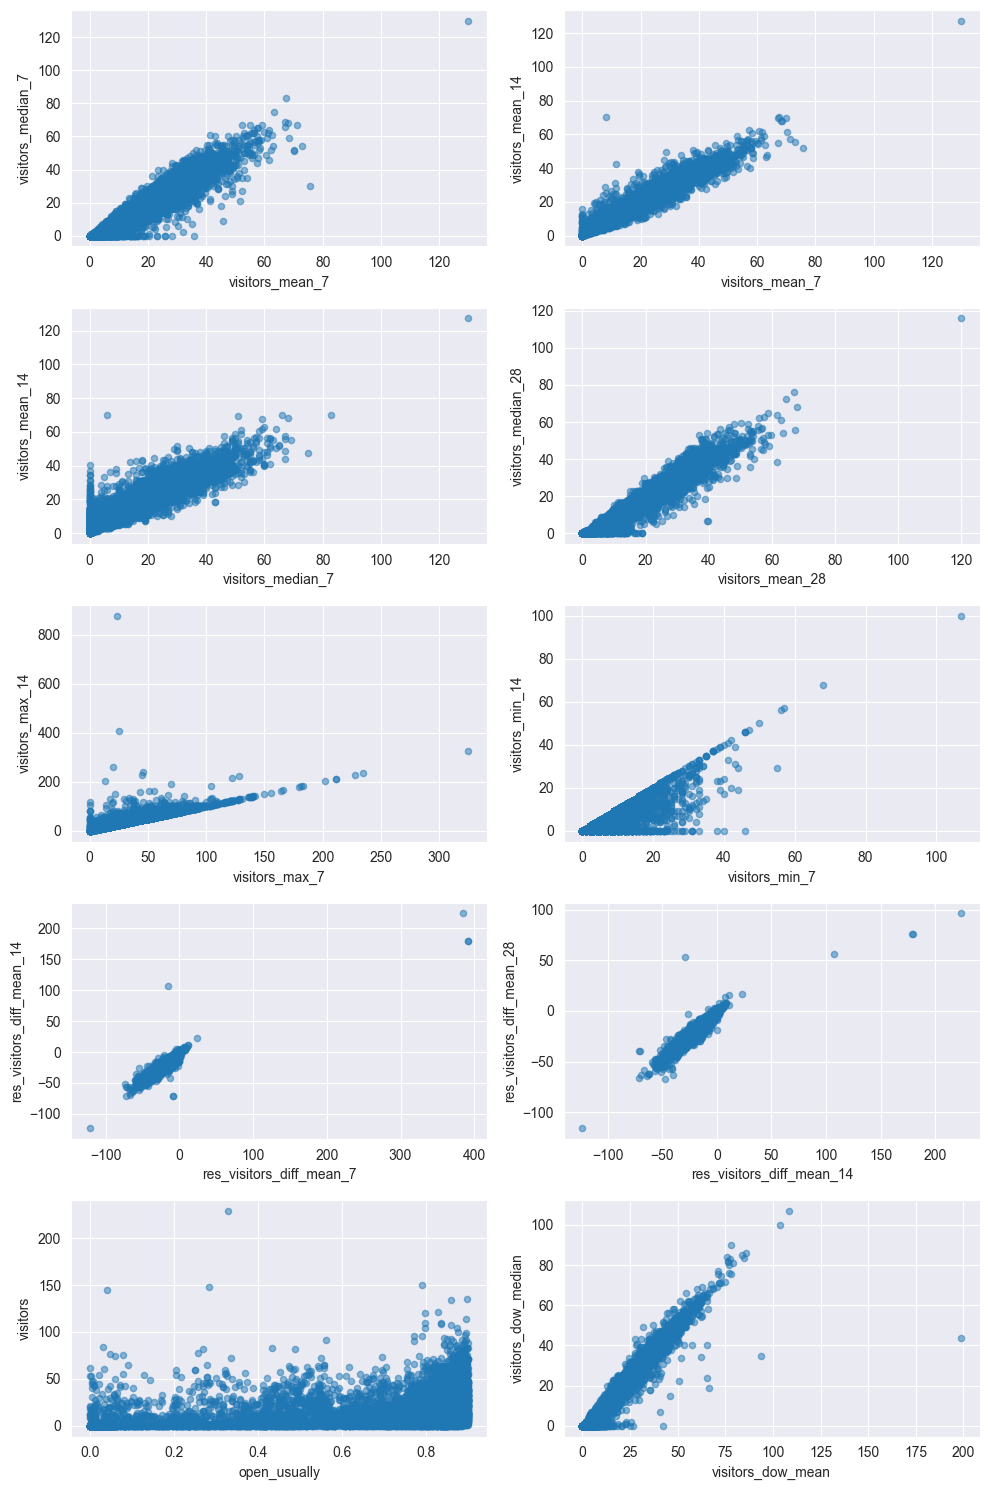

In [39]:
pairs = [
    ((MEAN_PREF, 7), (MEDIAN_PREF, 7)),
    ((MEAN_PREF, 7), (MEAN_PREF, 14)),
    ((MEDIAN_PREF, 7), (MEAN_PREF, 14)),
    ((MEAN_PREF, 28), (MEDIAN_PREF, 28)),
    ((MAX_PREF, 7), (MAX_PREF, 14)),
    ((MIN_PREF, 7), (MIN_PREF, 14))
]
pairs = [
    tuple(agg_window_col(VISITORS_COL, *item) for item in pair) for pair in pairs
]
res_means = [agg_window_col(RES_VISITORS_DIFF_COL, MEAN_PREF, w) for w in AGG_WINDOWS]
pairs += [*pairwise(res_means), (OPEN_USUALLY_COL, VISITORS_COL)]
pairs += [(agg_exp_col(VISITORS_DOW, MEAN_PREF), agg_exp_col(VISITORS_DOW, MEDIAN_PREF))]
plot_pairs_rel(pairs, sample)

Holiday flag feature has approximately the same number of visitors at both 1 and 0, so the feature is uncorrelated and likely unnecessary for the model. Reserve visitors difference mean 14 and visitors have a slightly elongated ellipsoid shape, indicating a relationship between the features.

Among the highly correlated features, the following can be retained: visitors_min_7 as more informative relative to visitors_min_14 (too many zeros can only interfere); max_7 as less noisy relative to max_14 and at the same time equally correlated with the target; mean_14 similarly relative to mean_7, median_7; median_28 similarly relative to mean_28; res_visitors_diff_mean_14 similarly relative to res_visitors_diff_mean_7, res_visitors_diff_mean_28; std_28 as the most correlated with the target and the least correlated with the selected max_14.

Open_usually feature now produces errors much less frequently at values close to zero. However, at higher values, there are still quite a lot of errors (0 visitors), but this is an improvement over the previous version of this feature.

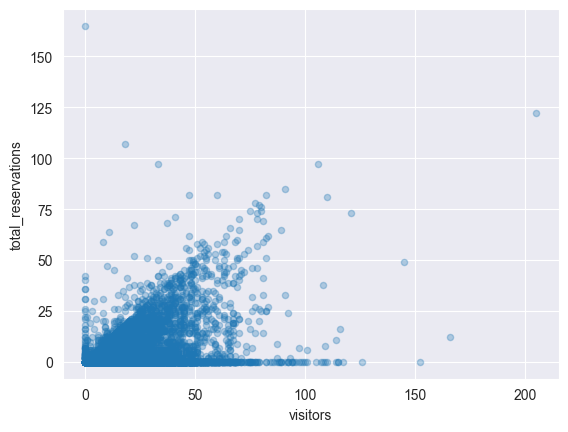

In [40]:
mask = air_visit_df[RES_IMPOSSIBILITY_COL] == 0
sample = air_visit_df[mask].sample(10000, random_state=RANDOM_SEED)
sample.plot.scatter(x=VISITORS_COL, y=TOTAL_RES_COL, alpha=0.3)
plt.show()

In [41]:
air_visit_df[mask][[VISITORS_COL, TOTAL_RES_COL]].corr()

,visitors,total_reservations
visitors,1.000000,0.307056
total_reservations,0.307056,1.000000


Even excluding restaurants for which reservations are impossible, the linear relationship between visitors and reservations is still weak (but the correlation is 0.13 higher than before the exclusion). However, we can see that there is a "boundary" above which the density of values is significantly lower. Situations where there are more reservations than visitors are less common, but not vice versa. There are also quite a few observations where the number of reservations is zero, but there are still many visitors. This isn't related to gaps in air_reserve, as we filled them previously.

### Open usually analysis

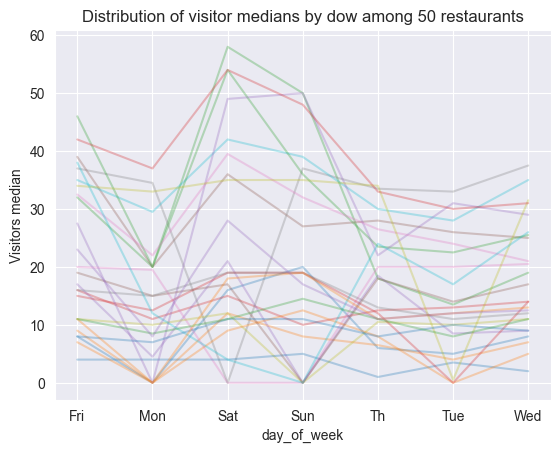

In [43]:
air_visit_df = add_closed_flg(air_visit_df)
opened = air_visit_df[air_visit_df[CLOSED_FLG] == 0]

sampled_restaurants = (
    opened[AIR_RESTAURANT_ID_COL]
    .drop_duplicates()
    .sample(25, random_state=RANDOM_SEED)
)
air_sample = opened[opened[AIR_RESTAURANT_ID_COL].isin(sampled_restaurants)]
dow_median = air_sample.groupby([AIR_RESTAURANT_ID_COL, DAY_OF_WEEK_COL])[
    VISITORS_COL
].median()
dow_median.unstack().T.plot(legend=False, alpha=0.3)
plt.title("Distribution of visitor medians by dow among 50 restaurants")
plt.ylabel("Visitors median")
plt.show()

Above are the visitor medians for a sample of restaurants by day of the week (order was ignored, as we're specifically looking for zeros). While this varies from restaurant to restaurant, there's a consistent pattern: a median of zero indicates the restaurant is likely closed that day - and there are quite a few of them.

#### Schedule changes

In [44]:
grouped = air_visit_df.groupby([AIR_RESTAURANT_ID_COL, DAY_OF_WEEK_COL])
vis_rolling = grouped.rolling(4)[VISITORS_COL].median()

In [45]:
vis_rolling.head()

air_store_id          day_of_week    
air_00a91d42b08b08d9  Fri          0      NaN
                                   7      NaN
                                   14     NaN
                                   21    38.5
                                   28    36.5
Name: visitors, dtype: float64

In [46]:
close_to_open = (vis_rolling != 0) & (vis_rolling.shift(1) == 0) & (vis_rolling.notna())
open_to_close = (vis_rolling == 0) & (vis_rolling.shift(1) != 0) & (vis_rolling.shift(1).notna())

In [47]:
close_to_open[close_to_open == True].head()

air_store_id          day_of_week      
air_00a91d42b08b08d9  Mon          206     True
air_0164b9927d20bcc3  Sat          350     True
                                   371     True
air_0241aa3964b7f861  Th           866     True
air_0328696196e46f18  Fri          1105    True
Name: visitors, dtype: bool

In [48]:
close_to_open.sum()

np.int64(2353)

In [49]:
open_to_close[open_to_close == True].head()

air_store_id          day_of_week     
air_00a91d42b08b08d9  Mon          192    True
air_0164b9927d20bcc3  Sat          343    True
                                   364    True
air_0241aa3964b7f861  Th           537    True
                                   908    True
Name: visitors, dtype: bool

In [50]:
open_to_close.sum()

np.int64(2360)

That's a total of about 4,000 cases where the schedule changed (for at least two-thirds times in a row) from open to closed and vice versa. These include both isolated incidents and general restaurant closures on all days of the week. These isolated changes sometimes include closed->open and open->closed (short-term schedule changes).

#### Feature versions

In [51]:
discrete_ver = add_open_usually_discr(air_visit_df).sample(10000, random_state=RANDOM_SEED)
dicr_roll = add_open_usually_discr_rolling(air_visit_df, 0.5).sample(10000, random_state=RANDOM_SEED)
continuous_ver = sample
rolling_ver = add_open_usually_col_rolling(air_visit_df).sample(10000, random_state=RANDOM_SEED)

Correlation with visitors: 0.29
Visitor mean on closing days: 1.83.
Visitor mean on opening days: 18.80.


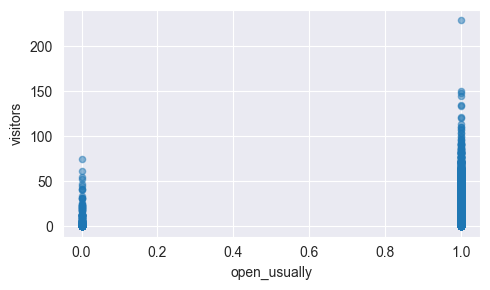

In [52]:
show_open_usually_stats(discrete_ver)

Correlation with visitors: 0.32
Visitor mean on closing days: 2.15.
Visitor mean on opening days: 19.19.


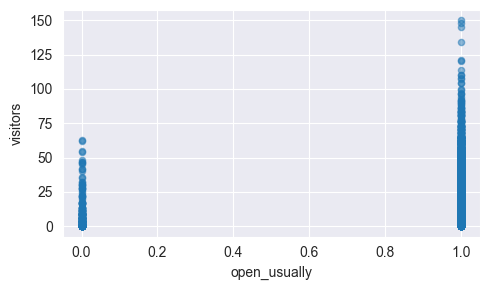

In [53]:
show_open_usually_stats(dicr_roll)

The discrete version of the feature without data leaks is slightly more correlated, but there are still situations where an actual of 0 predicts 1 and vice versa - these situations arise due to rare openings/closings of restaurants on days when the situation is usually different.

Correlation with visitors: 0.37
Visitor mean on closing days: 8.25.
Visitor mean on opening days: 21.95.


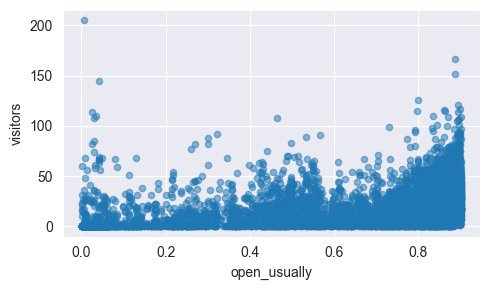

In [54]:
show_open_usually_stats(continuous_ver, 0.5)

The correlation between the continuous feature and the target became stronger. At the same time, the average number of visitors when predicting an closed day has increased (higher False Negatives, but lower False Positives), assuming a threshold of 0.5, though a different threshold may be chosen by the model itself. In this case, False Negatives will probably decrease, but False Positives may increase.

Since open_usually in its new version is correlated with visitors_dow_mean, we can check whether it adds any new information to the target or simply repeats the mentioned feature.

In [55]:
pg.partial_corr(air_visit_df, OPEN_USUALLY_COL, VISITORS_COL, agg_exp_col(VISITORS_DOW, MEAN_PREF))["r"]

pearson    0.063316
Name: r, dtype: float64

Since the partial correlation coefficient (excluding the influence of VISITORS_DOW_MEAN_COL) is practically zero, this feature, compared to VISITORS_DOW_MEAN_COL, does not contribute any new information. Overall, it can be removed in its current form.

Correlation with visitors: 0.37
Visitor mean on closing days: 8.57.
Visitor mean on opening days: 20.33.


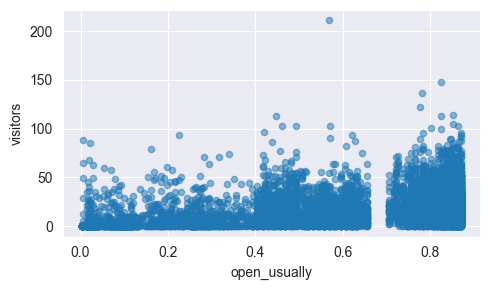

In [56]:
show_open_usually_stats(rolling_ver)

As a result, it is better to take the rolling discrete version of the feature, since its correlation is not much different from the others, there are no data leaks, and the mean of the feature is, in general, good at 0 and 1.

### Correlation difference after clustering

In [54]:
corr_before = pd.read_csv(
    PROJ_ROOT / "reports/tables/correlation_before_clustering.csv",
    index_col=0
)

In [55]:
corr_diff = (corr.abs() - corr_before.abs()).reindex(index=corr.index, columns=corr.columns).round(2)
plot_corr_matrix(corr_diff, 0.5)

City clustering had virtually no effect on the correlation of visitors with the other features. However, initially, the correlation with "neighboring" features was weak (shown previously in the graph). While previously restaurants with a small number of neighbors might have had clear differences in visitor numbers and "neighboring" features, now the effect may be similar but different: large cities outshine small ones. Because of this, "neighboring" features will always be disadvantaged for representatives of small cities, regardless of whether clustering was used. Later we could compare models with clustered and non-clustered cities.

It is also clear that the correlation of various features with std has decreased, which is expected, since after clustering we obtain n cities with a large number of restaurants, and the strong dispersion of small cities is simply leveled out.

### Unnecessary features

In [57]:
get_features_by_variance_threshold(air_visit_df, VARIANCE_FS_THRESHOLD)

['golden_week_flg', 'closed']

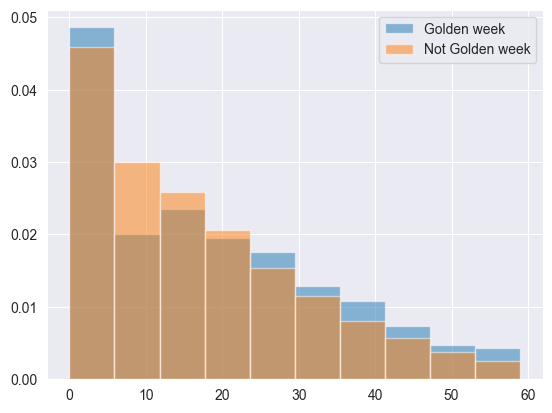

In [58]:
gw_mask = opened[GOLDEN_WEEK_FLG] == 1
gw_visitors = opened[gw_mask][VISITORS_COL]
visitors_no = get_non_outliers_mask(gw_visitors)
visitors_no_ngw = opened[VISITORS_COL] <= gw_visitors[visitors_no].max()
gw_visitors = gw_visitors[visitors_no]
ngw_visitors = opened[~gw_mask & visitors_no_ngw][VISITORS_COL]

gw_visitors.hist(alpha=0.5, density=True, label="Golden week")
ngw_visitors.hist(alpha=0.5, density=True, label="Not Golden week")
plt.legend()
plt.show()

The two samples are distributed slightly differently. During the golden week, values between 5 and 20 occur less frequently, but values outside this range (especially values greater than 25) occur more frequently. This feature can be retained because the golden week occurs once later in the test dataset, but it's not guaranteed to have any impact.

In [59]:
possibly_removable_features = get_features_by_target_corr(air_visit_df, TARGET_CORR_THRESHOLD)
possibly_removable_features

['opened_recently',
 'holiday_flg',
 'days_from_holiday',
 'golden_week_flg',
 'air_city_te',
 'air_genre_te',
 'reservation_impossibility_flag',
 'visitors_nbrs_mean_7',
 'visitors_nbrs_median_7',
 'visitors_nbrs_std_7',
 'visitors_nbrs_mean_14',
 'visitors_nbrs_median_14',
 'visitors_nbrs_std_14',
 'visitors_nbrs_mean_28',
 'visitors_nbrs_median_28',
 'visitors_nbrs_std_28',
 'visitors_nbrs_lag_1',
 'visitors_nbrs_lag_28',
 'visitors_nbrs_dow_std',
 'res_visitors_diff',
 'res_visitors_diff_mean_7',
 'res_visitors_diff_mean_14',
 'res_visitors_diff_mean_28',
 'nbr_res_visitors_diff',
 'nbr_res_visitors_diff_mean_7',
 'nbr_res_visitors_diff_mean_14',
 'nbr_res_visitors_diff_mean_28',
 'closed']

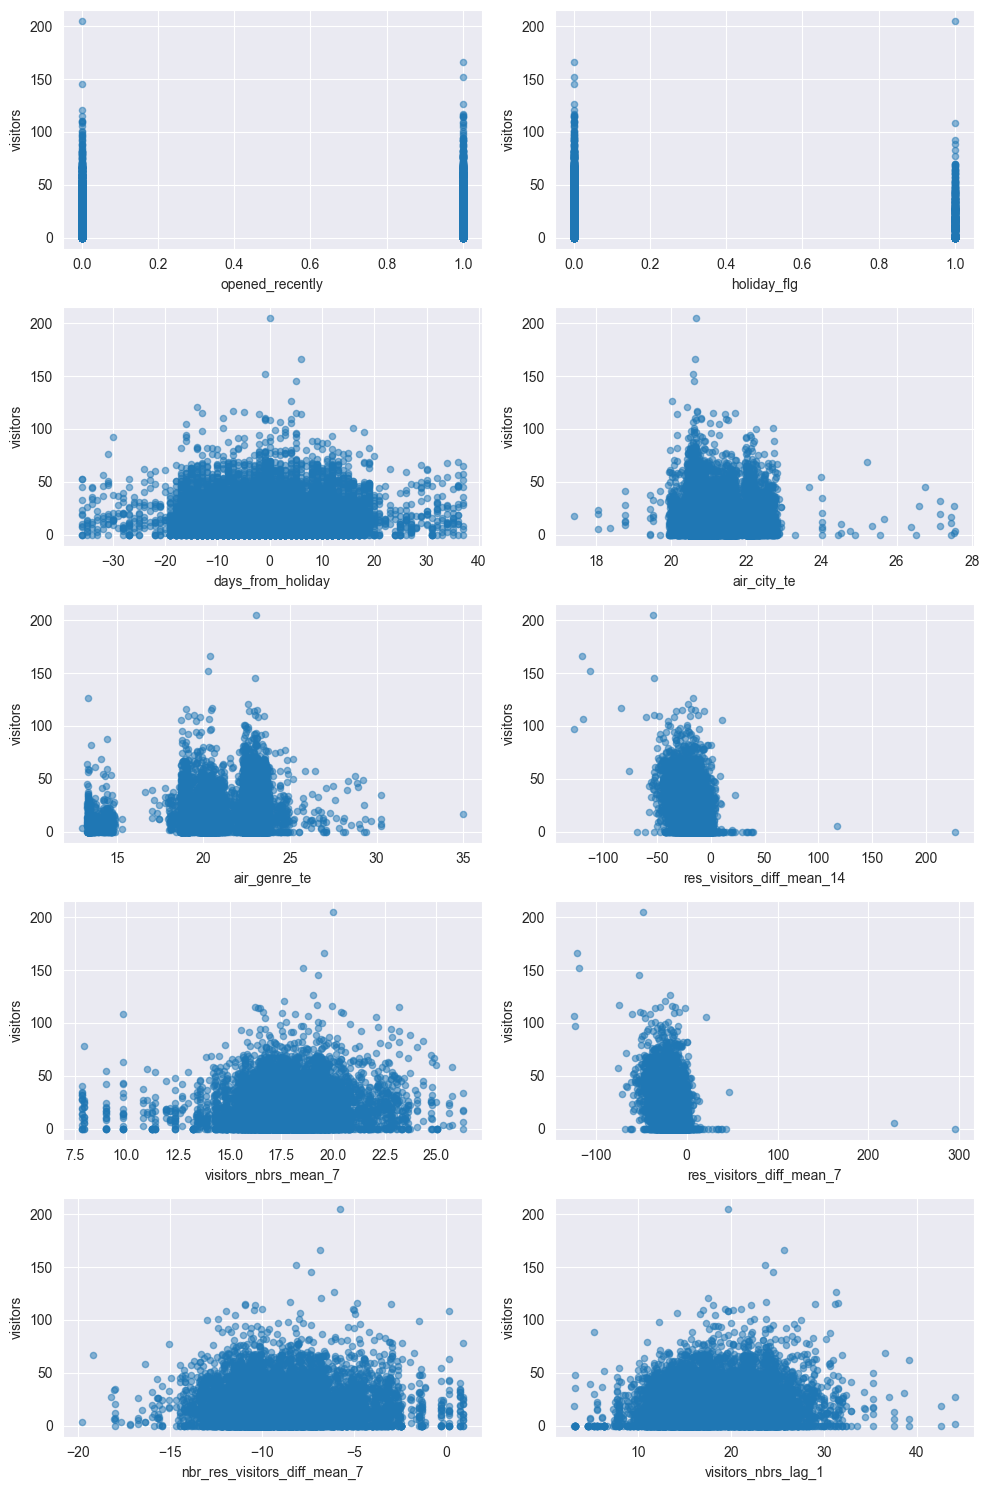

In [60]:
low_correlated_features = [
    OPENED_RECENTLY_FLG,
    HOLIDAY_COL,
    DAYS_FROM_HOL_COL,
    AREA_TE,
    GENRE_TE,
    res_means[1],
    agg_window_col(VISITORS_NBR_COL, MEAN_PREF, 7),
    agg_window_col(RES_VISITORS_DIFF_COL, MEAN_PREF, 7),
    agg_window_col(RES_VISITORS_DIFF_NBR_COL, MEAN_PREF, 7),
    agg_window_col(VISITORS_NBR_COL, "lag", 1),
]
pairs = [(col, VISITORS_COL) for col in low_correlated_features]
plot_pairs_rel(pairs, sample)

There is no linear or nonlinear relationship with any of the above features, so they can be removed. I only looked at the relationship with one of the mean_* features, as the features are correlated.

To determine whether the reservation_impossibility feature is useful, we need to look at records with 0 reservations (as this is precisely the situation for which the feature is designed). If reservation_impossibility and total_reservation are useful, then the distribution is expected to be different for zero reservations.

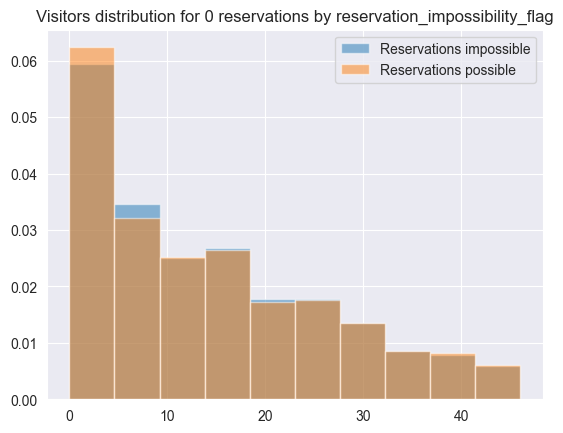

In [61]:
res_imp_visitors = get_visitors_by_zero_res(air_visit_df, True)
res_pos_visitors = get_visitors_by_zero_res(air_visit_df, False)

res_imp_visitors.hist(alpha=0.5, label="Reservations impossible", density=True)
res_pos_visitors.hist(alpha=0.5, label="Reservations possible", density=True)
plt.title(f"Visitors distribution for 0 reservations by {RES_IMPOSSIBILITY_COL}")
plt.legend()
plt.show()

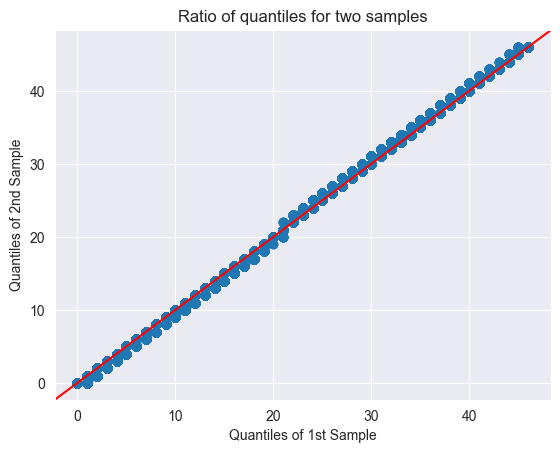

In [62]:
sm.qqplot_2samples(res_imp_visitors, res_pos_visitors, line="45")
plt.title("Ratio of quantiles for two samples")
plt.show()

The distribution of visitors with 0 reservations does not depend on whether bookings are possible or not. Therefore, the reservation_impossibility_flag flag, as uncorrelated and irrelevant, can also be removed.

In [63]:
possibly_removable_features.remove(GOLDEN_WEEK_FLG)
removed_features = [*possibly_removable_features, VISITORS_COL, VISITORS_NBR_COL]
features = air_visit_df.drop(columns=removed_features).select_dtypes(include='number')

select_by_vif(drop_first_month(air_visit_df).dropna(), features.columns.to_list())

['golden_week_flg',
 'open_usually',
 'total_reservations',
 'total_reservations_nbrs',
 'visitors_median_7',
 'visitors_std_7',
 'visitors_min_7',
 'visitors_min_14',
 'visitors_max_28',
 'visitors_min_28',
 'visitors_last_month',
 'visitors_lag_1',
 'visitors_lag_7',
 'visitors_lag_28',
 'visitors_nbrs_lag_7',
 'visitors_dow_median',
 'visitors_dow_std',
 'visitors_dow_std_4']

Those multicollinear features that were not selected after VIF can also be removed.

As a result, features with a weak influence on the target (primarily linear, but also graphically other types) were preliminarily removed. The golden_week_flg feature, although it has very low variance (due to the rarity of the event), was retained because it still tends to have a larger number of visitors than usual.

Features that would theoretically form a pair of influence on the target were tested once – reservation_impossibility and total_reservations. They had no influence in the pair (and, accordingly, the remaining features related to reservations are unlikely to form a pair with reservation_impossibility).

After VIF selection on the remaining features, we have 16 features that are free of multicollinearity and have a normal relationship with the target.

More than half of the developed features (36, to be precise) turned out to be unnecessary. This suggests that we can try to come up with some new combinations, aggregations, and reconsider the approach to creating some features.

## Saving

#### NaN dropping

In [35]:
air_visit_df = drop_first_month(air_visit_df).dropna()
air_visit_df = air_visit_df.sort_values(VISIT_DATE_COL)
air_visit_df.head()

,air_store_id,visit_date,visitors,open_date,opened_recently,day_of_week,holiday_flg,days_from_holiday,golden_week_flg,air_genre_name,...,visitors_dow_mean,visitors_dow_mean_nbrs,res_visitors_diff,res_visitors_diff_mean_7,res_visitors_diff_mean_14,res_visitors_diff_mean_28,nbr_res_visitors_diff,nbr_res_visitors_diff_mean_7,nbr_res_visitors_diff_mean_14,nbr_res_visitors_diff_mean_28
244410,air_d0e8a085d8dc83aa,2016-02-01,10,2016-01-01,1,Mon,0,-10,0,Cafe/Sweets,...,15.75,16.126276,-18.0,-13.857143,-12.428571,-11.857143,-15.816327,-11.452008,-11.328331,-12.117069
253575,air_db4b38ebe7a7ceff,2016-02-01,14,2016-01-01,1,Mon,0,-10,0,Dining bar,...,12.00,16.126276,-10.0,-6.142857,-5.928571,-6.964286,-15.816327,-11.452008,-11.328331,-12.117069
241908,air_cfdeb326418194ff,2016-02-01,3,2016-01-01,1,Mon,0,-10,0,Bar/Cocktail,...,5.25,13.531875,0.0,-11.857143,-10.500000,-9.571429,-7.960708,-9.767062,-9.584126,-10.784374
61980,air_39dccf7df20b1c6a,2016-02-01,26,2016-01-01,1,Mon,0,-10,0,Izakaya,...,24.75,16.126276,-38.0,-18.714286,-21.928571,-23.571429,-15.816327,-11.452008,-11.328331,-12.117069
237464,air_cb7467aed805e7fe,2016-02-01,16,2016-01-01,1,Mon,0,-10,0,Izakaya,...,16.75,15.011974,-21.0,-30.142857,-27.428571,-25.821429,-9.822421,-7.854981,-8.580150,-10.476121


In [36]:
air_visit_df = air_visit_df.drop(columns=[OPEN_DATE_COL])
labels = air_visit_df[VISITORS_COL].copy()
features = air_visit_df.drop(columns=[VISITORS_COL])
future_df = future_df.drop(columns=[OPEN_DATE_COL, "id", VISITORS_COL])
future_df[TOTAL_RES_NBR_COL] = future_df[TOTAL_RES_NBR_COL].fillna(0)
features.to_csv(PROCESSED_DATA_DIR / "features.csv", index=False)
labels.to_csv(PROCESSED_DATA_DIR / "labels.csv", index=False)
future_df.to_csv(PROCESSED_DATA_DIR / "test_features.csv", index=False)

## Conclusion

### Added features.

- Operating schedule - regular working days, extracted from the regular gaps in the data frame.
- Days to/from the nearest holiday (negative is days until, positive is days after).
- Holiday indicator (currently included in date_info).
- Separate indicators for Golden Week dates.

- Number of visitors on this day last month for this restaurant.

- Indicator of whether the restaurant has been open within the last 6 months.
- Days since last recorded visit for air_visit dataframe.

- Rolling mean/median/std of visitors over the past week, month - for this restaurant/for neighbors.
- Historical day-of-week mean up to (but not including) the current day - for this restaurant/for neighbors.
- Rolling reserve/visitors difference over the past 7 / 28 days - for this restaurant/for neighbors.
- Lag 1, 7, 28 of the number of visitors - for this restaurant/for neighbors.

- Smoothed target encoding of visitors by air_area_name.
- Smoothed target encoding of visitors by air_genre_name.

- Total reserved visitors (from air_reserve and hpg_reserve) on this day - for this restaurant/for neighbors.

### Features planned for addition.

- Days since last recorded visit for sample_submission.

### Possible features.

- Daily temperature - try to get the weather forecast.
- Precipitation probability.
- Hpg genre.

Decomposition features:
- Trend.
- Trend difference for last month.
- Seasonal.
- Residual mean for last month.